# Multi-Layer Perceptron (MLP) for Wave Parameter Prediction

This notebook implements a supervised deep learning model for predicting wave parameters using compressed features from a pretrained autoencoder. The MLP architecture enables accurate forecasting of critical oceanographic variables for the Azores region.

## Model Overview

- **Input**: 32-dimensional latent features from autoencoder (compressed spatiotemporal patterns)
- **Target Variables**: Mean wave period (mwp), significant wave height (swh), and mean wave direction (mwd)
- **Architecture**: Three-layer fully connected network with dropout regularization
- **Training Strategy**: Early stopping with validation monitoring to prevent overfitting

## Workflow

1. Load and normalize input/target datasets
2. Encode features using pretrained autoencoder
3. Train MLP with validation split
4. Evaluate predictions with comprehensive metrics
5. Visualize temporal patterns and error distributions

In [15]:
# Core libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# Visualization
import matplotlib.pyplot as plt

In [16]:
# Set random seeds for reproducibility
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seeds set to {SEED} for reproducibility")

Random seeds set to 42 for reproducibility


## 1. Data Loading

### 1.1 Load Prepared Datasets

Load preprocessed training and testing datasets generated in the previous notebook. Each sample contains spatiotemporal features from a 3×3 grid over 2 time steps, with corresponding target wave parameters for 1 time step ahead.

In [17]:
# Configuration parameters
NEIGH_LAT, NEIGH_LON = 1, 1  # Spatial neighborhood size (3×3 grid)
TIME_HORIZON = 2  # Historical time steps
PREDICTED_HORIZON = 1  # Prediction horizon (1 time step ahead)
VARS = ["u10", "v10", "mwp", "swh", "mwd_sin", "mwd_cos"]
VARS_PRED = ["mwp", "swh", "mwd_sin", "mwd_cos"]
DATA_FOLDER = 'dataset_final'
N_TRAIN_SAMPLES = 10000
N_TEST_SAMPLES = 2000

# Load training dataset
Xtr = np.load(f"{DATA_FOLDER}/MLP_train_data_{N_TRAIN_SAMPLES}_{VARS}_X.npy")
ytr = np.load(f"{DATA_FOLDER}/MLP_train_data_{N_TRAIN_SAMPLES}_{VARS}_y.npy")

# Load testing dataset
Xte = np.load(f"{DATA_FOLDER}/MLP_test_data_{N_TEST_SAMPLES}_{VARS}_X.npy")
yte = np.load(f"{DATA_FOLDER}/MLP_test_data_{N_TEST_SAMPLES}_{VARS}_y.npy")

# Dataset information
target_dim = ytr.shape[1]

print("Dataset Information")
print("=" * 60)
print(f"Variables (input): {VARS}")
print(f"Variables (target): {VARS_PRED}")
print(f"Spatial grid: {2*NEIGH_LAT+1}×{2*NEIGH_LON+1} points")
print(f"Temporal horizon: {TIME_HORIZON} steps → {PREDICTED_HORIZON} step ahead")
print(f"\nTraining data:")
print(f"  Input shape: {Xtr.shape}")
print(f"  Target shape: {ytr.shape}")
print(f"\nTesting data:")
print(f"  Input shape: {Xte.shape}")
print(f"  Target shape: {yte.shape}")
print(f"\nTarget dimension: {target_dim}")

Dataset Information
Variables (input): ['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos']
Variables (target): ['mwp', 'swh', 'mwd_sin', 'mwd_cos']
Spatial grid: 3×3 points
Temporal horizon: 2 steps → 1 step ahead

Training data:
  Input shape: (10000, 108)
  Target shape: (10000, 4)

Testing data:
  Input shape: (2000, 108)
  Target shape: (2000, 4)

Target dimension: 4


## 2. Data Normalization

Apply standardization to both input features and target variables to improve training stability and convergence:
- **Input variables**: Normalized using pretrained scaler from the autoencoder pipeline
- **Target variables**: Normalized using a new StandardScaler fitted to the training data

In [18]:
import joblib

# Load pretrained scaler from autoencoder pipeline
scaler = joblib.load("model/scaler2.save")

Xtr_all = Xtr.reshape(Xtr.shape[0], TIME_HORIZON, 9 , len(VARS))
Xtr_feat = Xtr.reshape(-1, len(VARS))

Xte_all = Xte.reshape(Xte.shape[0], TIME_HORIZON, 9 , len(VARS))
Xte_feat = Xte.reshape(-1, len(VARS))
# Transform input data
Xtr_scaled = torch.tensor(scaler.transform(Xtr_feat), dtype=torch.float32)
Xte_scaled = torch.tensor(scaler.transform(Xte_feat), dtype=torch.float32)

# Fit scaler for target variables
scaler_y = StandardScaler()
ytr_scaled = scaler_y.fit_transform(ytr.reshape(-1, target_dim))
yte_scaled = scaler_y.transform(yte.reshape(-1, target_dim))

print(f"Scaled training targets shape: {ytr_scaled.shape}")
print(f"Scaled testing targets shape: {yte_scaled.shape}")

Scaled training targets shape: (10000, 4)
Scaled testing targets shape: (2000, 4)


In [19]:
Xtr_scaled_all = Xtr_scaled.reshape(Xtr.shape[0], TIME_HORIZON, 9 , len(VARS))
Xte_scaled_all = Xte_scaled.reshape(Xte.shape[0], TIME_HORIZON, 9 , len(VARS))

Xtr_scaled_sample = Xtr_scaled_all.reshape(Xtr.shape)
Xte_scaled_sample = Xte_scaled_all.reshape(Xte.shape)

print(Xtr_scaled_sample.shape)
print(Xte_scaled_sample.shape)

torch.Size([10000, 108])
torch.Size([2000, 108])


## 3. Feature Encoding with Autoencoder

Utilize the pretrained autoencoder to compress high-dimensional input features into a lower-dimensional latent representation. This reduces computational complexity while preserving essential information.

In [20]:
class Autoencoder(nn.Module):
    """
    Autoencoder architecture for dimensionality reduction.
    
    Args:
        input_size (int): Dimension of input features
        encoded_size (int): Dimension of latent representation
    """
    def __init__(self, input_dim, latent_dim, hidden_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder: compress to latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, latent_dim),
            nn.ReLU()
        )
        
        # Decoder: reconstruct from latent space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### Load Pretrained Autoencoder

Load the trained autoencoder model and encode both training and testing datasets into their latent representations.

In [21]:
# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained autoencoder
autoencoder = Autoencoder(input_dim=Xtr_scaled_sample.shape[1], latent_dim=32, hidden_dim=128).to(device)
autoencoder.load_state_dict(torch.load("model/autoencoder_model2.pth", map_location=device))
autoencoder.eval()

print(f"Original feature dimension: {Xtr.shape[1]}")

# Encode features
with torch.no_grad():
    Xtr_encoded = autoencoder.encoder(Xtr_scaled_sample.to(device)).cpu()
    Xte_encoded = autoencoder.encoder(Xte_scaled_sample.to(device)).cpu()

print(f"Encoded feature dimension: {Xtr_encoded.shape[1]}")

Original feature dimension: 108
Encoded feature dimension: 32


C:\Users\berna\AppData\Local\Temp\ipykernel_35268\1606257253.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load("model/autoencoder_mo

## 4. MLP Architecture

Define an improved Multi-Layer Perceptron with regularization techniques including dropout layers to prevent overfitting. The model consists of three fully connected layers with ReLU activation functions.

In [22]:
class ImprovedMLP(nn.Module):
    """
    Multi-Layer Perceptron with dropout regularization.
    
    Args:
        input_dim (int): Input feature dimension
        hidden_dim (int): Hidden layer dimension
        output_dim (int): Output dimension
        dropout (float): Dropout rate for regularization
    """
    def __init__(self, input_dim, hidden_dim=256, output_dim=1, dropout=0.1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout/2),
            nn.Linear(hidden_dim//2, output_dim)
        )
    
    def forward(self, x):
        return self.model(x)

# Model configuration
USE_ENCODED = True  # Use autoencoder's latent representation

if USE_ENCODED:
    INPUT_DIM = 32  # Encoded feature dimension
    input_data_train = Xtr_encoded
    input_data_test = Xte_encoded
    print("Using encoded features (32D)")
else:
    INPUT_DIM = Xtr_scaled.shape[1]  # Raw feature dimension
    input_data_train = Xtr_scaled
    input_data_test = Xte_scaled
    print(f"Using raw scaled features ({INPUT_DIM}D)")

OUTPUT_DIM = target_dim  # Number of target variables
HIDDEN_DIM = 256
DROPOUT = 0.05

print(f"\nMLP Architecture:")
print(f"  Input dimension: {INPUT_DIM}")
print(f"  Hidden dimension: {HIDDEN_DIM}")
print(f"  Output dimension: {OUTPUT_DIM}")
print(f"  Dropout rate: {DROPOUT}")

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mlp = ImprovedMLP(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, 
                   output_dim=OUTPUT_DIM, dropout=DROPOUT).to(device)

Using encoded features (32D)

MLP Architecture:
  Input dimension: 32
  Hidden dimension: 256
  Output dimension: 4
  Dropout rate: 0.05


## 5. Model Training

### 5.1 Training Setup

Configure data loaders, loss function (MSE), optimizer (Adam), and learning rate scheduler. The dataset is split into training (80%) and validation (20%) sets to monitor model performance.

In [23]:
def to_float_tensor(x):
    """Convert numpy array or tensor to float tensor."""
    if isinstance(x, torch.Tensor):
        return x.detach().float()
    else:
        return torch.from_numpy(x).float()

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    input_data_train, ytr_scaled, test_size=0.2, random_state=42
)

# Training configuration
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# Create data loaders
train_loader = DataLoader(
    TensorDataset(to_float_tensor(X_train), to_float_tensor(y_train)),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(to_float_tensor(X_val), to_float_tensor(y_val)),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Data Split Configuration")
print("=" * 60)
print(f"Training samples:   {len(train_loader.dataset):,} (80%)")
print(f"Validation samples: {len(val_loader.dataset):,} (20%)")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler - reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20
)

print(f"\nOptimization Setup:")
print(f"  Loss function:  MSE (Mean Squared Error)")
print(f"  Optimizer:      Adam (lr={LEARNING_RATE})")
print(f"  LR Scheduler:   ReduceLROnPlateau (factor=0.5, patience=20)")

Data Split Configuration
Training samples:   8,000 (80%)
Validation samples: 2,000 (20%)
Batch size:         64
Training batches:   125
Validation batches: 32

Optimization Setup:
  Loss function:  MSE (Mean Squared Error)
  Optimizer:      Adam (lr=0.001)
  LR Scheduler:   ReduceLROnPlateau (factor=0.5, patience=20)


### 5.2 Training Loop

Execute the training process with early stopping mechanism to prevent overfitting. The model is trained using MSE loss and validated at each epoch. Best model weights are preserved based on validation performance.

In [24]:
# Training configuration
NUM_EPOCHS = 1000
PATIENCE = 50

train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Training Configuration")
print("=" * 60)
print(f"Maximum epochs:     {NUM_EPOCHS}")
print(f"Early stopping:     {PATIENCE} epochs patience")
print(f"Device:             {device}")
print(f"\nStarting training...\n")

for epoch in range(NUM_EPOCHS):
    # Training phase
    mlp.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = mlp(xb)
        if pred.shape != yb.shape:
            pred = pred.squeeze()
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_loss_history.append(train_loss)
    
    # Validation phase
    mlp.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = mlp(xb)
            if pred.shape != yb.shape:
                pred = pred.squeeze()
            loss = criterion(pred, yb)
            val_loss += loss.item() * xb.size(0)
    
    val_loss /= len(val_loader.dataset)
    val_loss_history.append(val_loss)
    
    # Update learning rate based on validation performance
    scheduler.step(val_loss)
    
    # Early stopping with best model tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = mlp.state_dict().copy()
        if (epoch + 1) % 50 == 0 or epoch < 5:
            print(f"Epoch {epoch+1:4d}/{NUM_EPOCHS} | Train: {train_loss:.6f} | Val: {val_loss:.6f} ✓")
    else:
        patience_counter += 1
        if (epoch + 1) % 50 == 0 or epoch < 5:
            print(f"Epoch {epoch+1:4d}/{NUM_EPOCHS} | Train: {train_loss:.6f} | Val: {val_loss:.6f} ({patience_counter}/{PATIENCE})")
        
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"Best validation loss: {best_val_loss:.6f}")
            break

# Restore best model weights
if best_model_state is not None:
    mlp.load_state_dict(best_model_state)
    print(f"\nRestored best model (Val Loss: {best_val_loss:.6f})")

Training Configuration
Maximum epochs:     1000
Early stopping:     50 epochs patience
Device:             cuda

Starting training...

Epoch    1/1000 | Train: 0.086469 | Val: 0.012357 ✓
Epoch    2/1000 | Train: 0.017246 | Val: 0.009966 ✓
Epoch    3/1000 | Train: 0.013957 | Val: 0.008275 ✓
Epoch    4/1000 | Train: 0.012386 | Val: 0.007389 ✓
Epoch    5/1000 | Train: 0.011420 | Val: 0.007562 (1/50)
Epoch   50/1000 | Train: 0.006569 | Val: 0.005890 (5/50)
Epoch  100/1000 | Train: 0.005819 | Val: 0.007299 (12/50)
Epoch  150/1000 | Train: 0.004890 | Val: 0.004775 (10/50)
Epoch  200/1000 | Train: 0.004128 | Val: 0.004062 (6/50)
Epoch  250/1000 | Train: 0.004043 | Val: 0.003894 ✓
Epoch  300/1000 | Train: 0.003890 | Val: 0.003852 ✓
Epoch  350/1000 | Train: 0.003856 | Val: 0.003853 (7/50)

Early stopping at epoch 393
Best validation loss: 0.003837

Restored best model (Val Loss: 0.003837)



Figures saved: training_history.pdf, training_history.png
  Best val loss:     0.003837
  Final train loss:  0.003812
  Total epochs:      393

Training Summary:


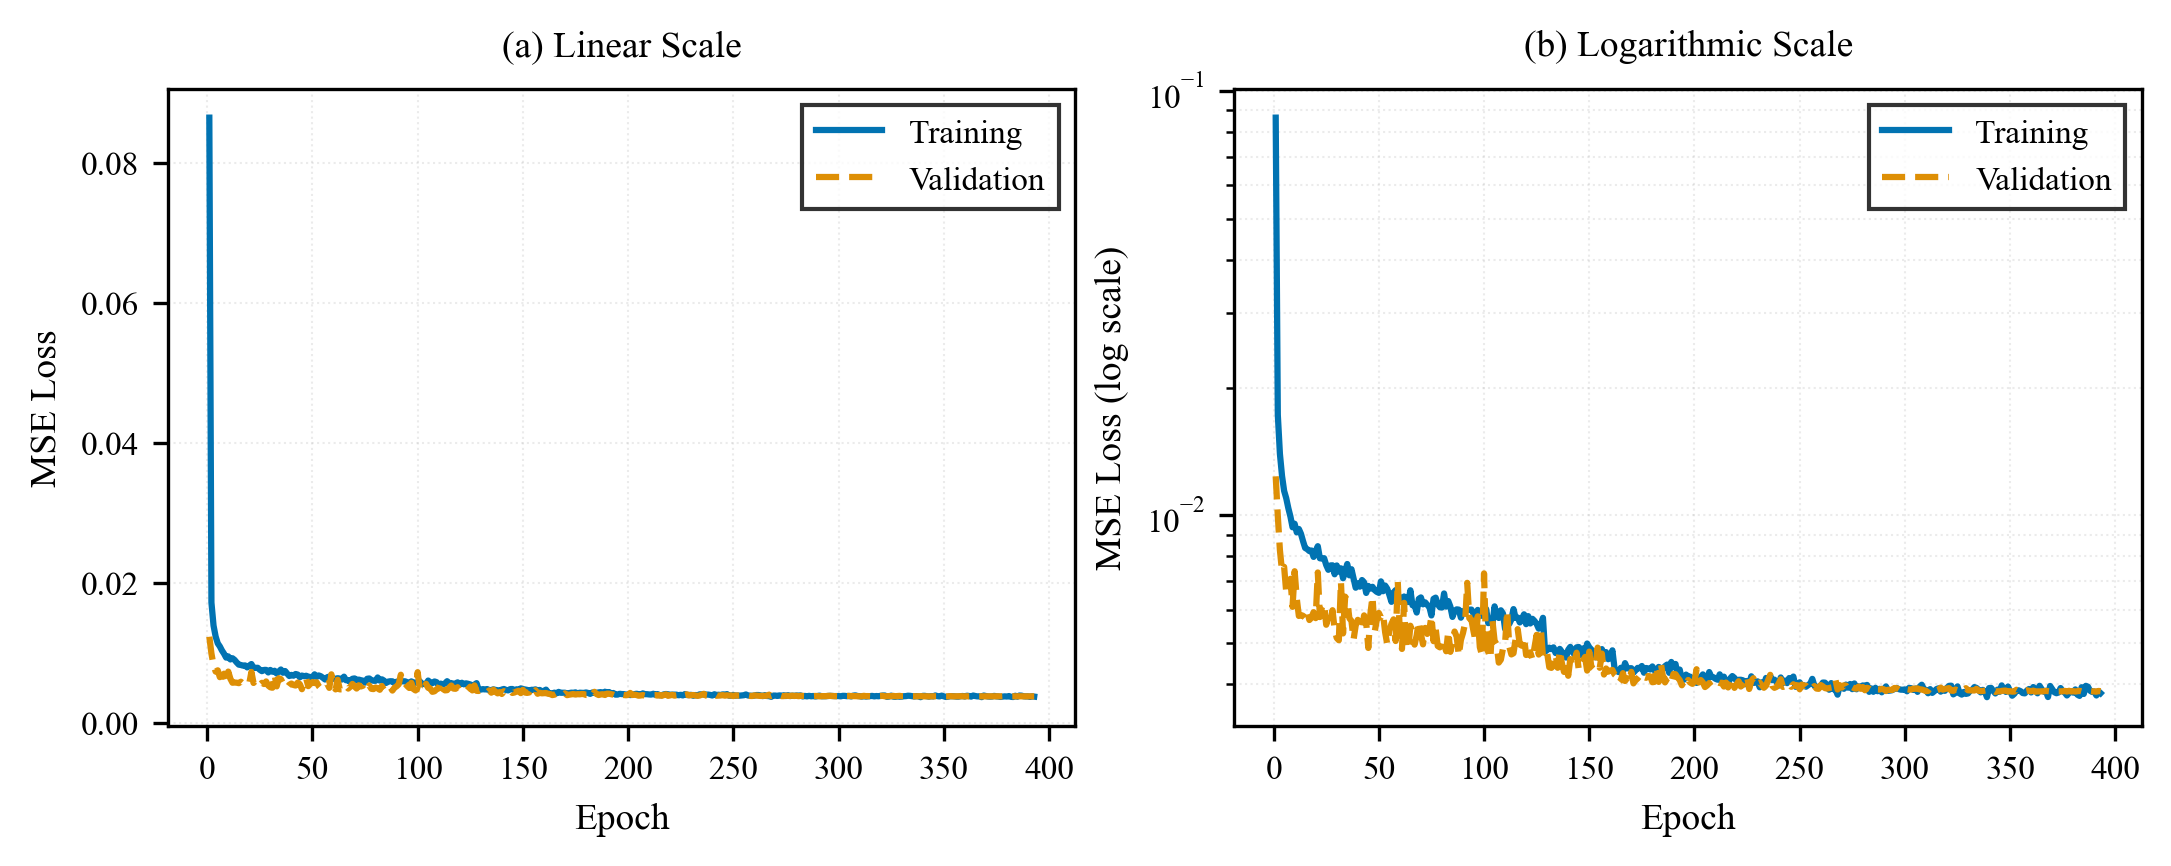

In [25]:
### 5.3 Training History Visualization

# IEEE publication settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'stix'

epochs = range(1, len(train_loss_history) + 1)

# IEEE column width: 3.5 inches, two-column figure: 7.16 inches
fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.8), dpi=300)

# IEEE-compliant colors (colorblind-friendly)
color_train = '#0173B2'  # Blue
color_val = '#DE8F05'    # Orange

# Linear scale
axes[0].plot(epochs, train_loss_history, label='Training', 
             linewidth=1.5, color=color_train)
axes[0].plot(epochs, val_loss_history, label='Validation', 
             linewidth=1.5, color=color_val, linestyle='--')
axes[0].set_title('(a) Linear Scale', fontsize=9, pad=8)
axes[0].set_xlabel('Epoch', fontsize=9)
axes[0].set_ylabel('MSE Loss', fontsize=9)
axes[0].tick_params(labelsize=8)
axes[0].grid(True, alpha=0.25, linestyle=':', linewidth=0.5)
axes[0].legend(fontsize=8, loc='best', frameon=True, edgecolor='black', fancybox=False)

# Log scale for better visibility of convergence
axes[1].plot(epochs, train_loss_history, label='Training', 
             linewidth=1.5, color=color_train)
axes[1].plot(epochs, val_loss_history, label='Validation', 
             linewidth=1.5, color=color_val, linestyle='--')
axes[1].set_title('(b) Logarithmic Scale', fontsize=9, pad=8)
axes[1].set_xlabel('Epoch', fontsize=9)
axes[1].set_ylabel('MSE Loss (log scale)', fontsize=9)

axes[1].set_yscale('log')
print(f"\nFigures saved: training_history.pdf, training_history.png")

axes[1].tick_params(labelsize=8)
print(f"  Best val loss:     {best_val_loss:.6f}")

axes[1].grid(True, alpha=0.25, which='both', linestyle=':', linewidth=0.5)
print(f"  Final train loss:  {train_loss_history[-1]:.6f}")
axes[1].legend(fontsize=8, loc='best', frameon=True, edgecolor='black', fancybox=False)
print(f"  Total epochs:      {len(train_loss_history)}")

print(f"\nTraining Summary:")

plt.tight_layout(pad=0.5)

plt.savefig('images, figures and videos2/MLP_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Prediction and Denormalization

Generate predictions on the test dataset and transform them back to the original scale using inverse scaling. This step is essential for interpreting results in physical units.

In [26]:
# Generate predictions on test set
test_input = torch.tensor(input_data_test, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_scaled = mlp(test_input).cpu().numpy()
    y_pred_scaled = y_pred_scaled.reshape(-1, target_dim)

# Inverse transform to original scale
y_true = scaler_y.inverse_transform(yte_scaled.reshape(-1, target_dim))
y_pred = scaler_y.inverse_transform(y_pred_scaled)

print(f"Predictions shape: {y_pred.shape}")
print(f"True values shape: {y_true.shape}")

Predictions shape: (2000, 4)
True values shape: (2000, 4)


C:\Users\berna\AppData\Local\Temp\ipykernel_35268\3595021994.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_input = torch.tensor(input_data_test, dtype=torch.float32).to(device)


## 7. Model Evaluation and Visualization

### 7.1 Direction Reconstruction

Convert sine and cosine components back to directional angles and prepare data for comprehensive evaluation.

In [27]:
def convert_to_direction(sin_values, cos_values):
    """Convert sine and cosine components to direction angle in degrees (0-360)."""
    angles = np.degrees(np.arctan2(sin_values, cos_values))
    return (angles + 360) % 360

def unwrap_angles(true_angles, pred_angles):
    """Unwrap predicted angles to avoid discontinuities near 0/360 degrees."""
    pred_unwrapped = pred_angles.copy()
    for i in range(len(true_angles)):
        diff = pred_unwrapped[i] - true_angles[i]
        if diff > 180:
            pred_unwrapped[i] -= 360
        elif diff < -180:
            pred_unwrapped[i] += 360
    return pred_unwrapped

# Convert predictions and true values to numpy arrays
yte = np.array(yte)
y_pred = np.array(y_pred)

# Convert sin/cos components to direction angle
yte_direction = convert_to_direction(yte[:, 2], yte[:, 3])
y_pred_direction = convert_to_direction(y_pred[:, 2], y_pred[:, 3])

# Unwrap predicted directions
y_pred_direction = unwrap_angles(yte_direction, y_pred_direction)

# Combine variables: mwp, swh, mwd
yte_merged = np.column_stack([yte[:, 0], yte[:, 1], yte_direction])
y_pred_merged = np.column_stack([y_pred[:, 0], y_pred[:, 1], y_pred_direction])

vars_pred = ["mwp", "swh", "mwd"]
print(f"Evaluation variables: {vars_pred}")
print(f"Data shape: {yte_merged.shape}")

Evaluation variables: ['mwp', 'swh', 'mwd']
Data shape: (2000, 3)



 Variable: MWP — Mean Wave Period (s)
  MSE  : 0.0097
  RMSE : 0.0984
  NRMSE : 0.0107
  MAE  : 0.0743
  NMAE : 0.0081
  R²   : 0.9955
  Figures saved for MWP

 Variable: SWH — Significant Wave Height (m)
  MSE  : 0.0038
  RMSE : 0.0613
  NRMSE : 0.0078
  MAE  : 0.0445
  NMAE : 0.0057
  R²   : 0.9977
  Figures saved for SWH

 Variable: MWD — Mean Wave Direction (°)
  MSE  : 6.5632
  RMSE : 2.5619
  NRMSE : 0.0071
  MAE  : 1.5574
  NMAE : 0.0043
  R²   : 0.9994
  Figures saved for MWD


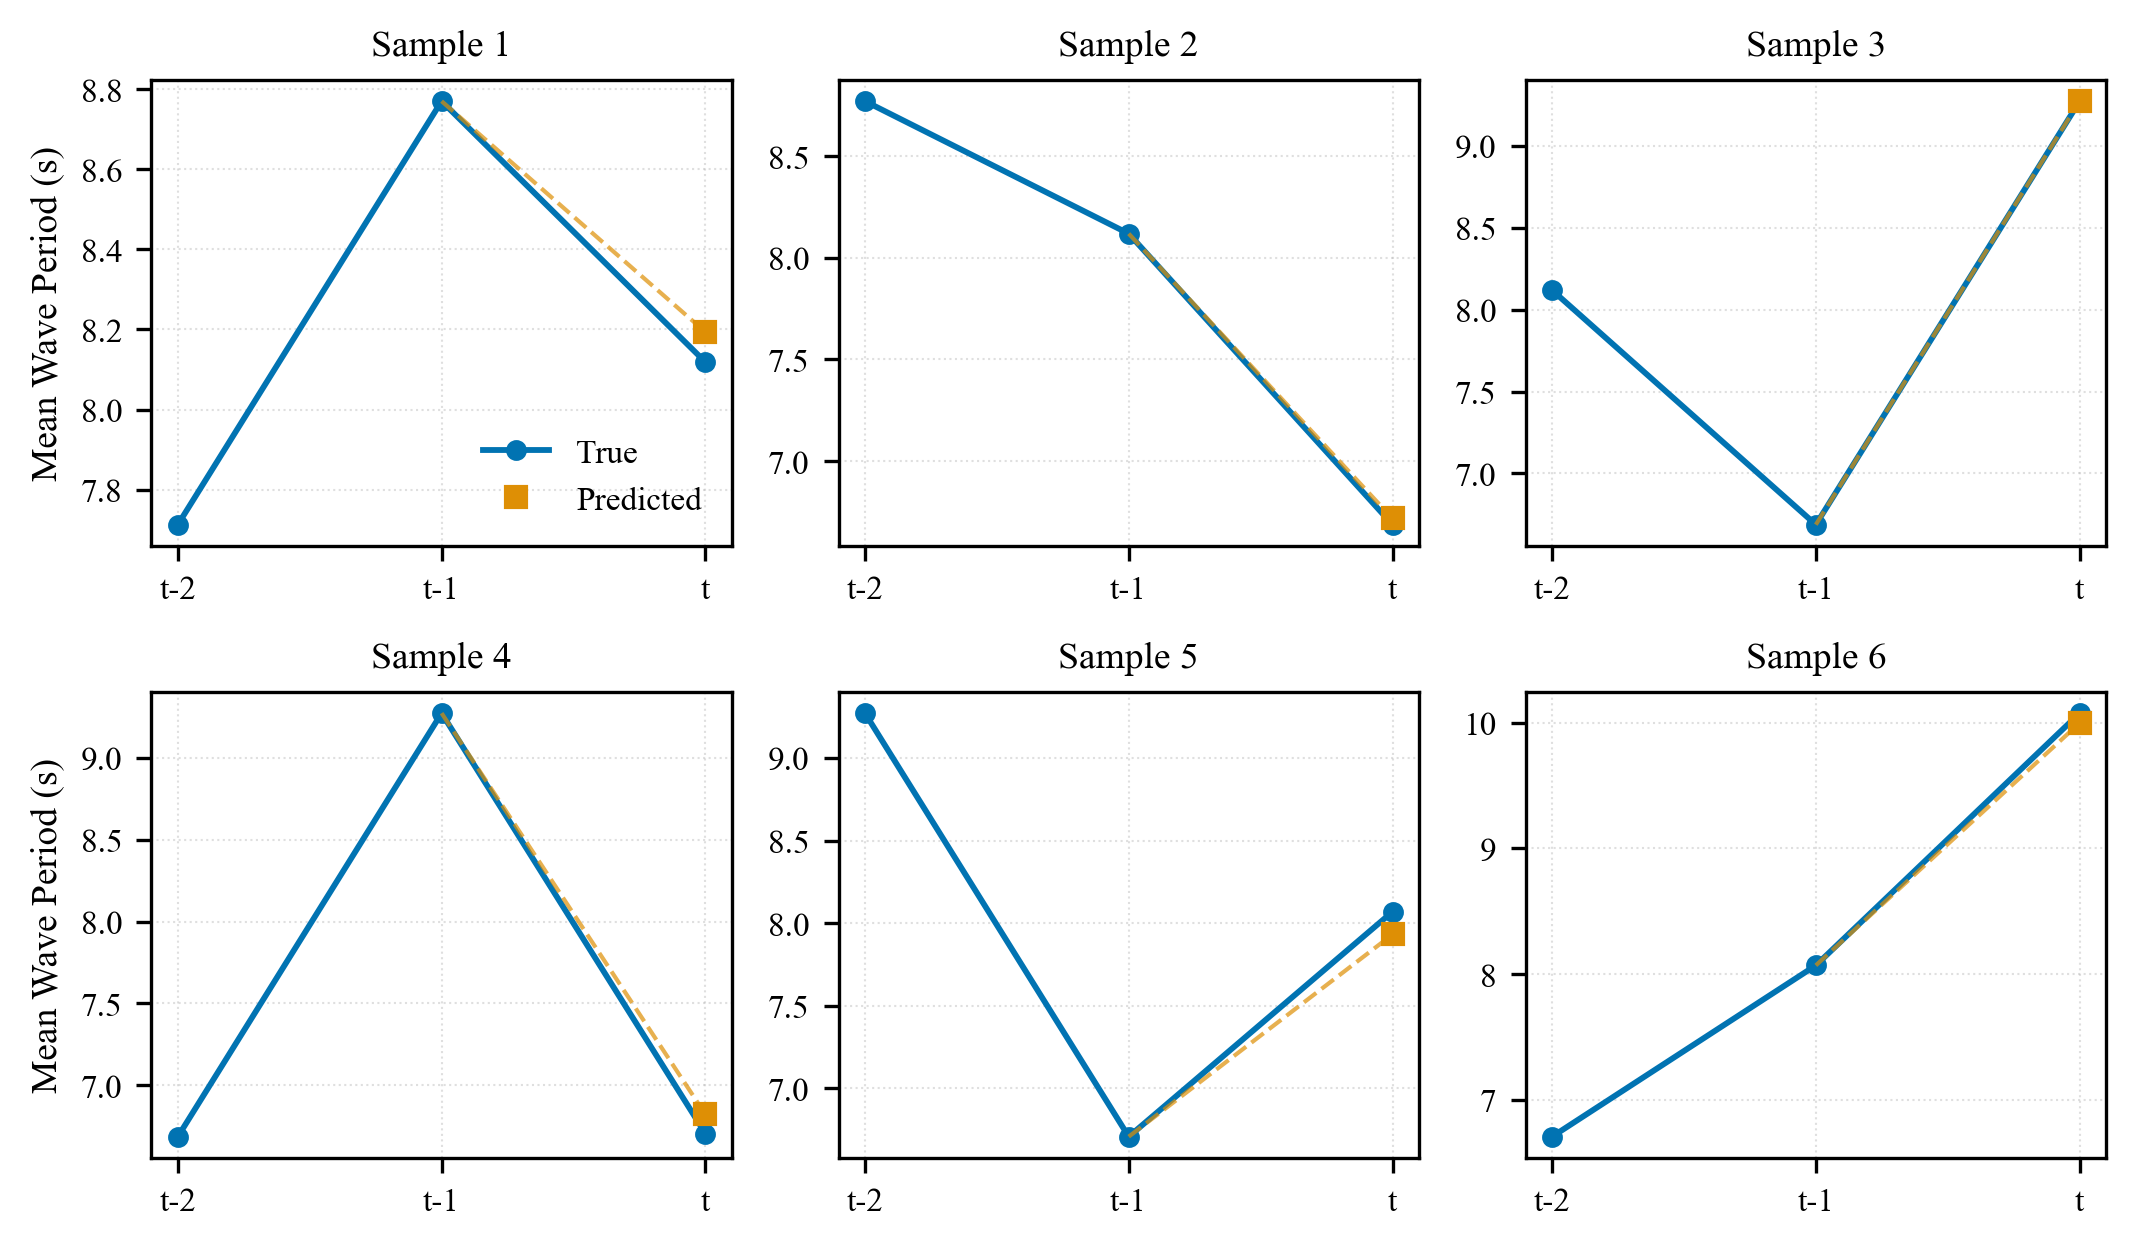

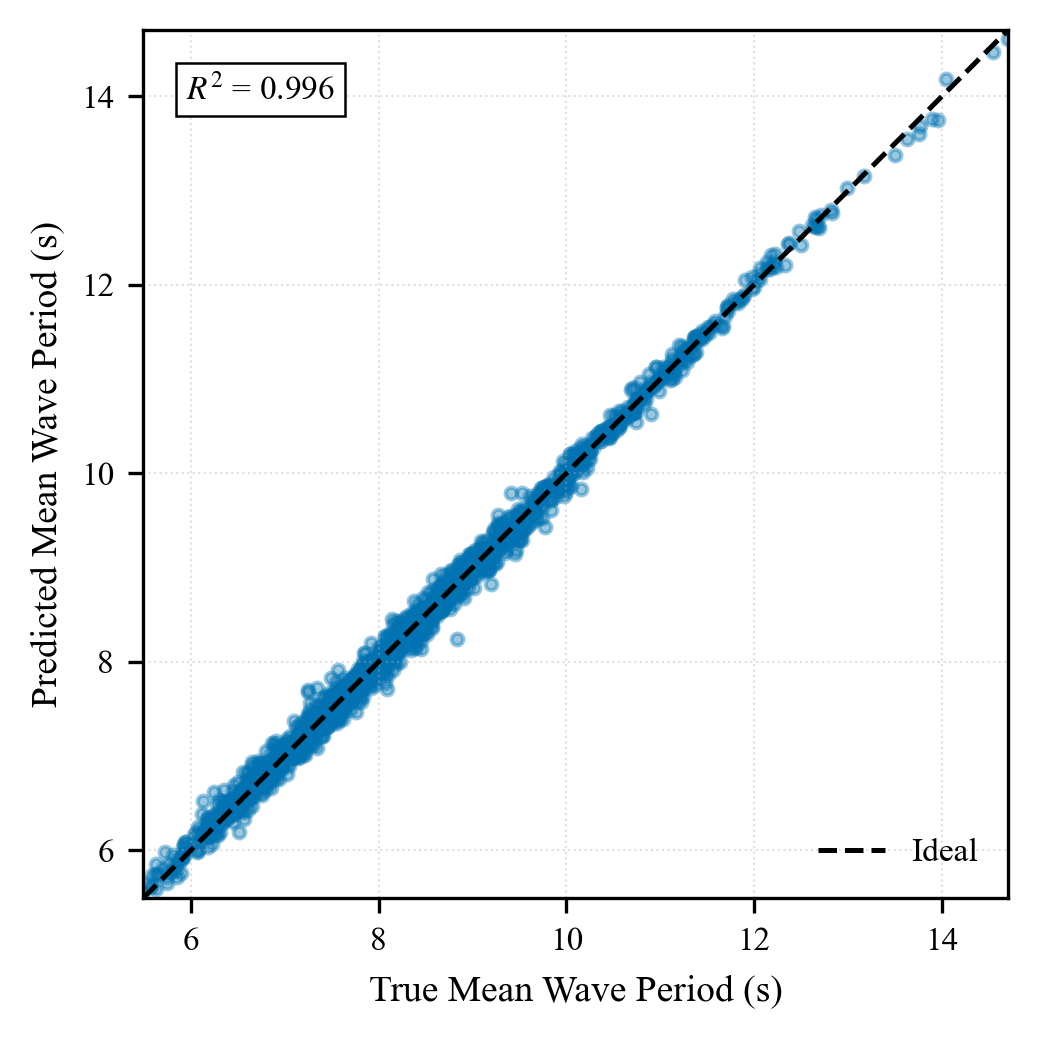

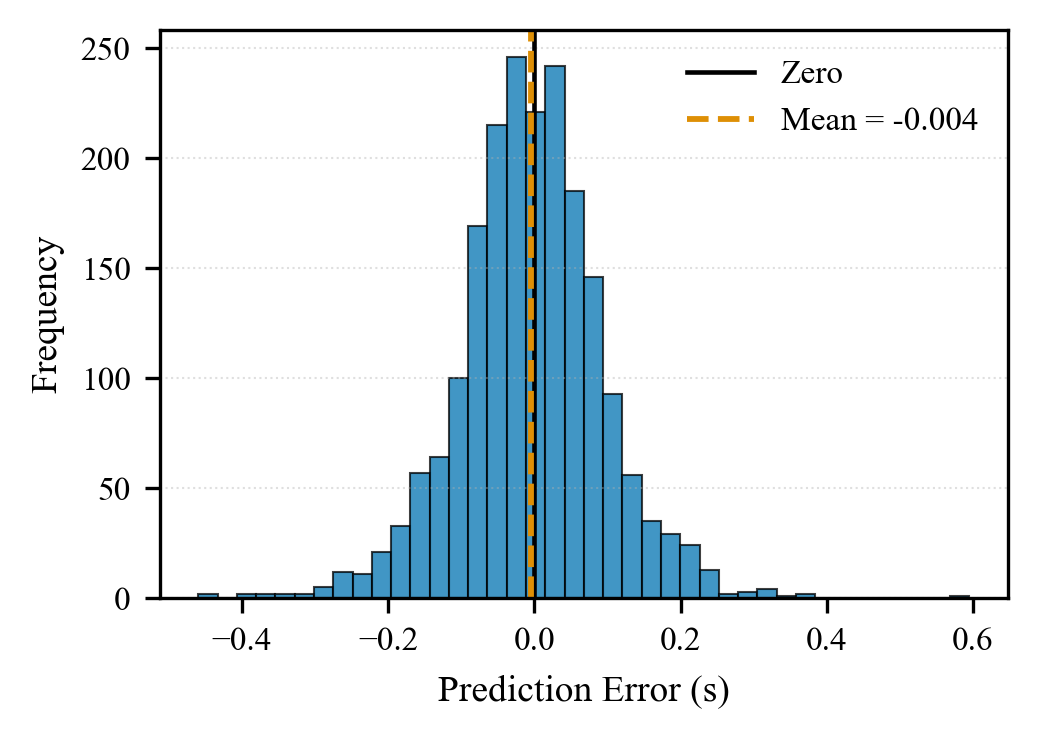

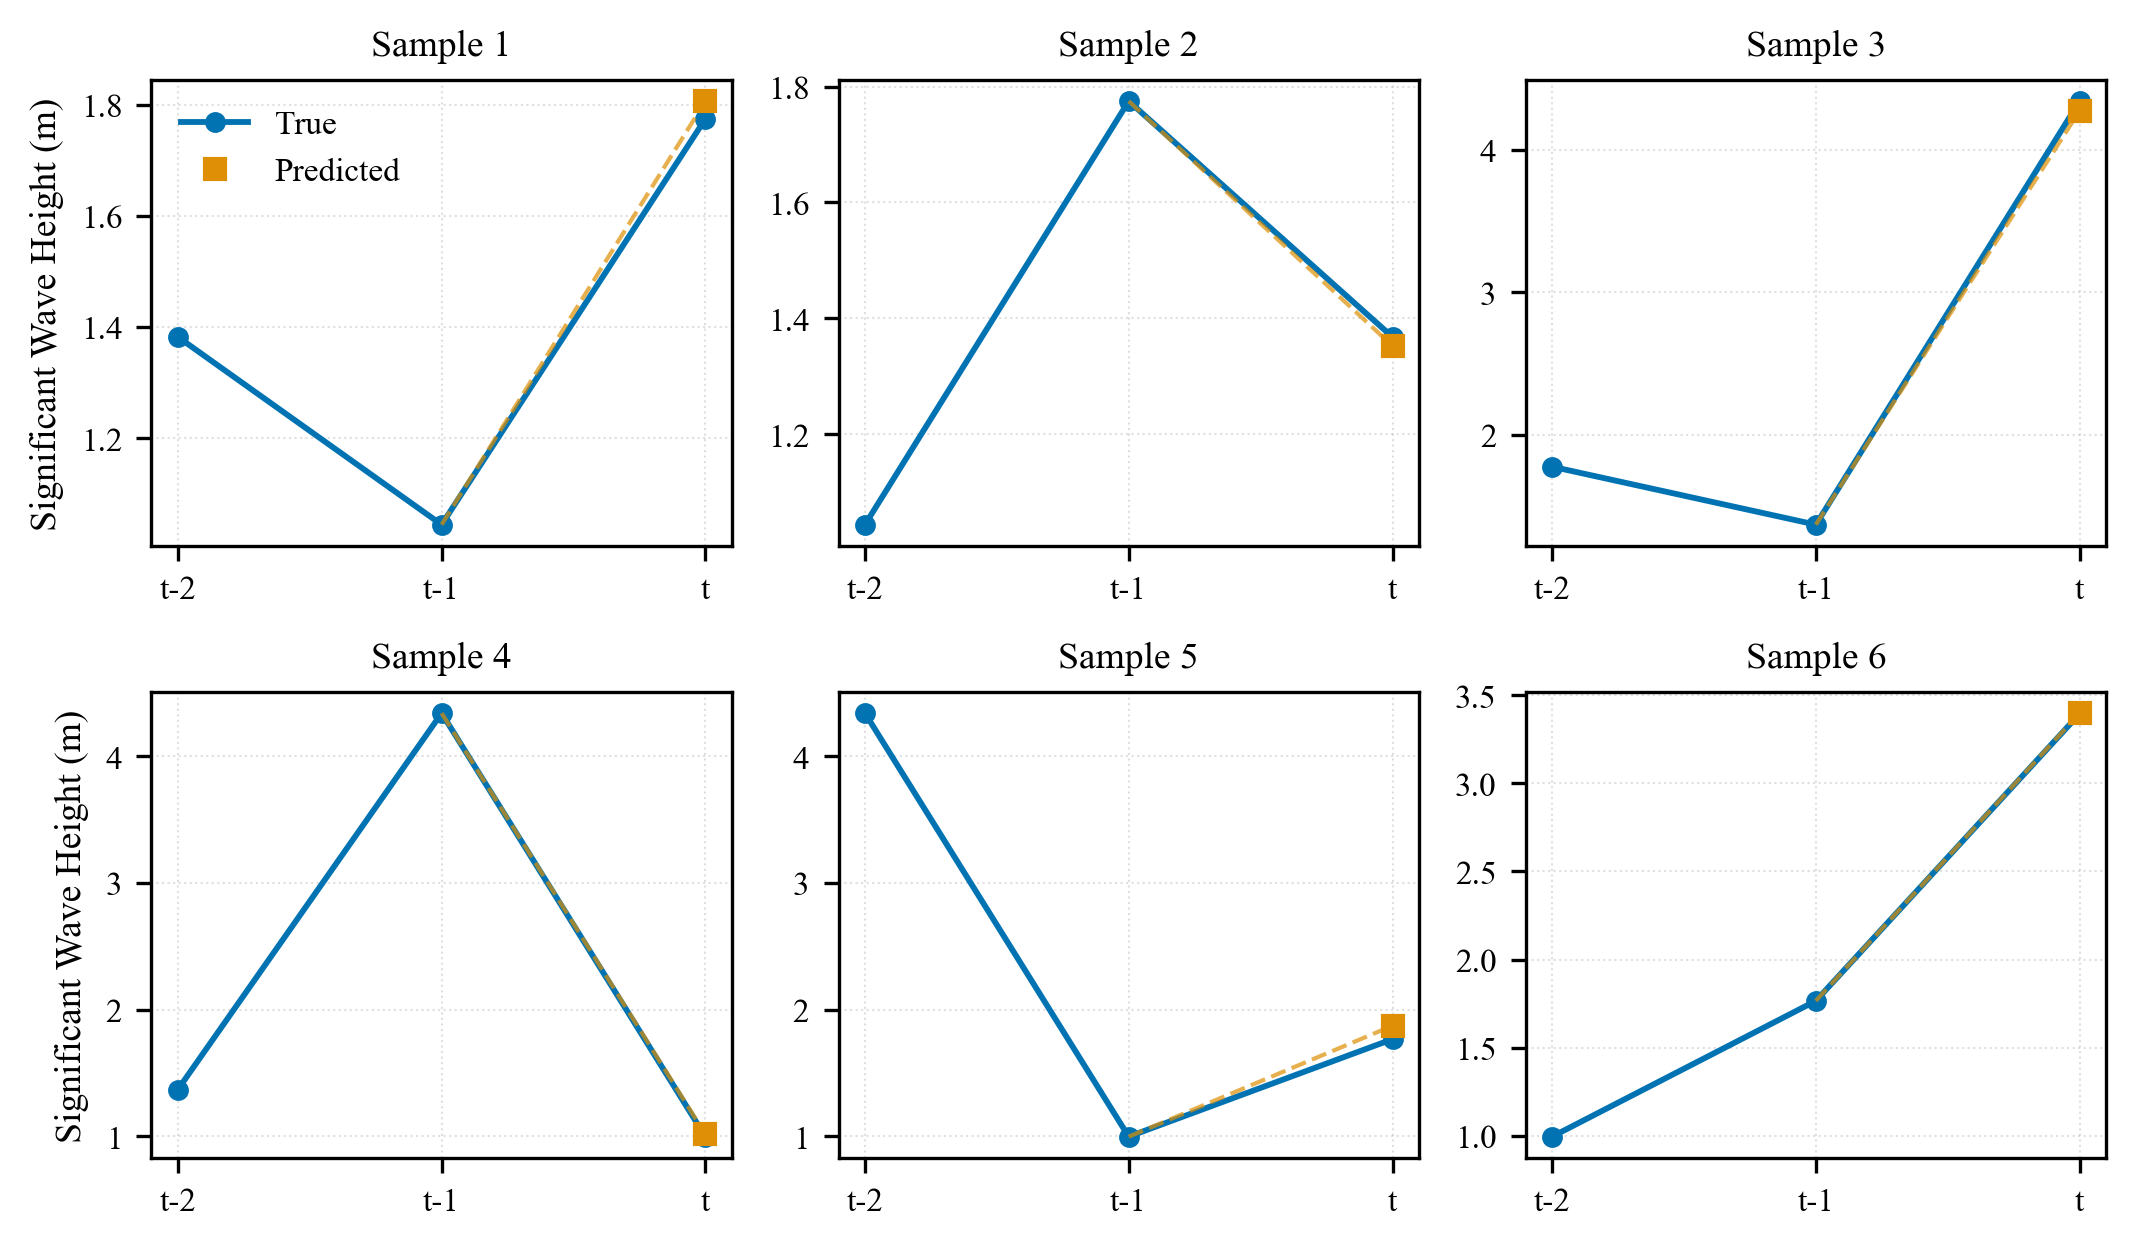

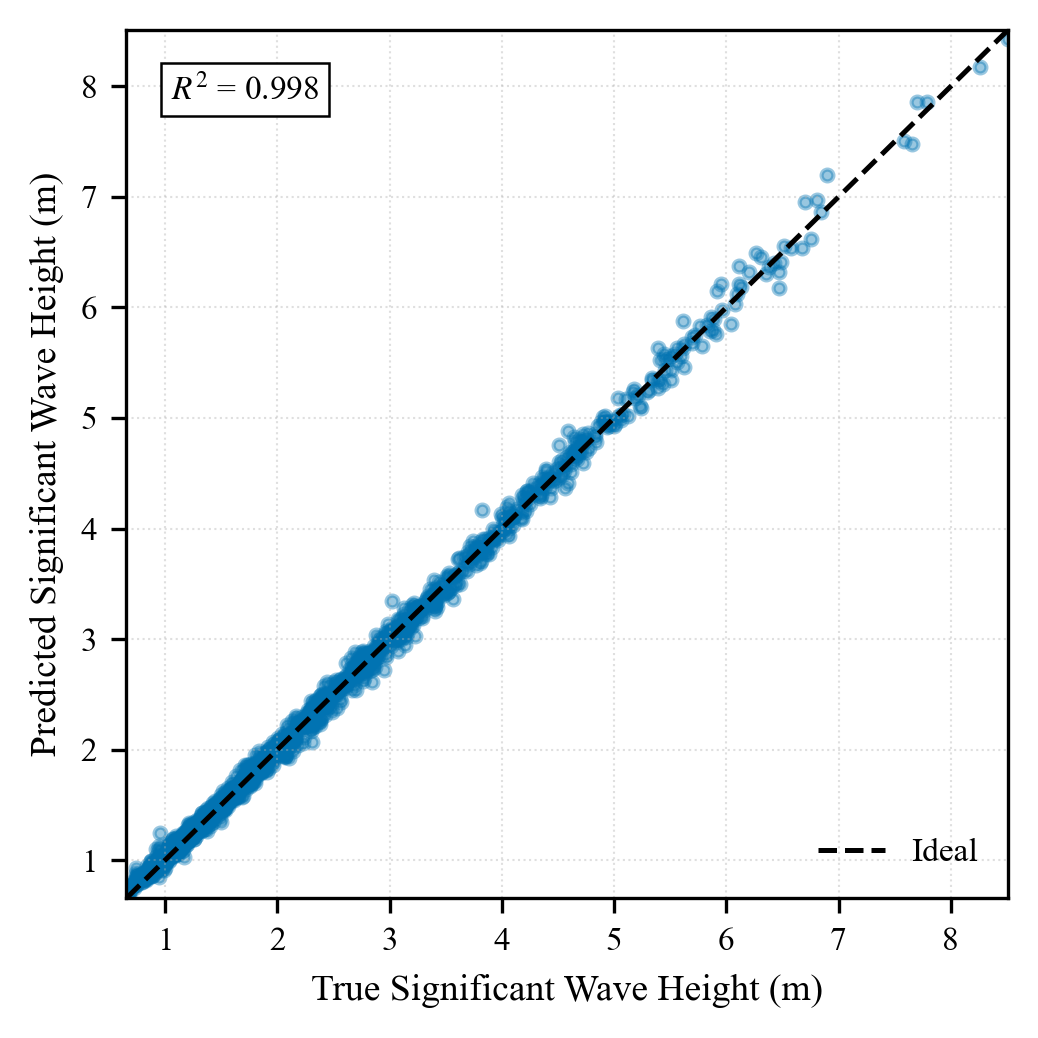

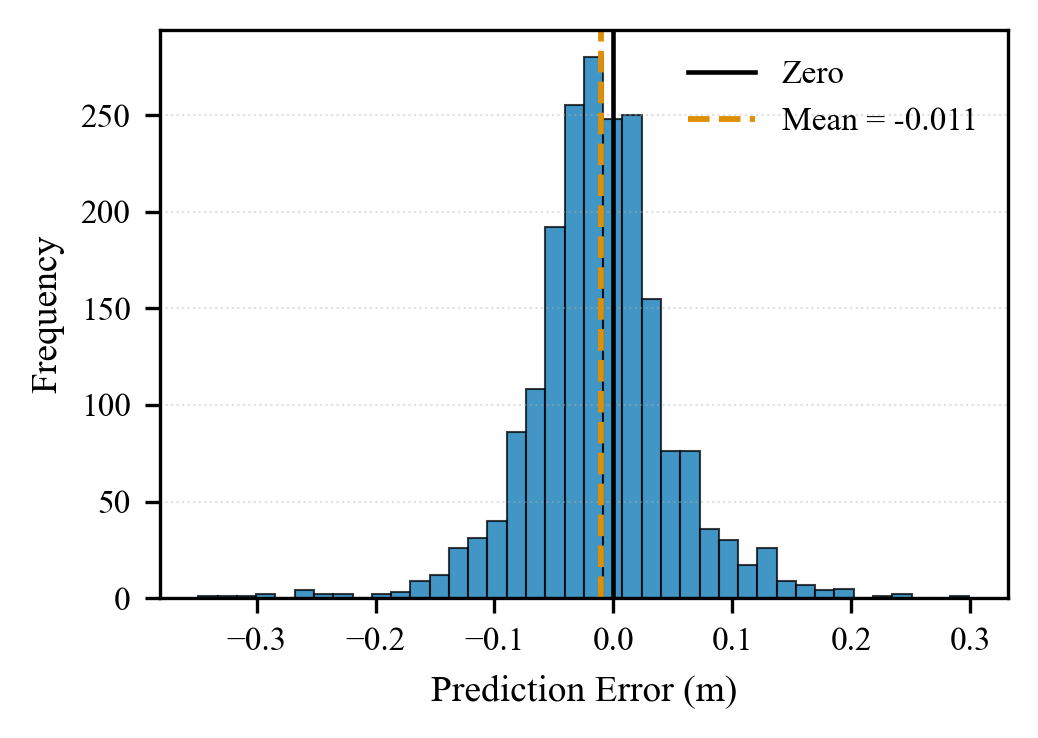

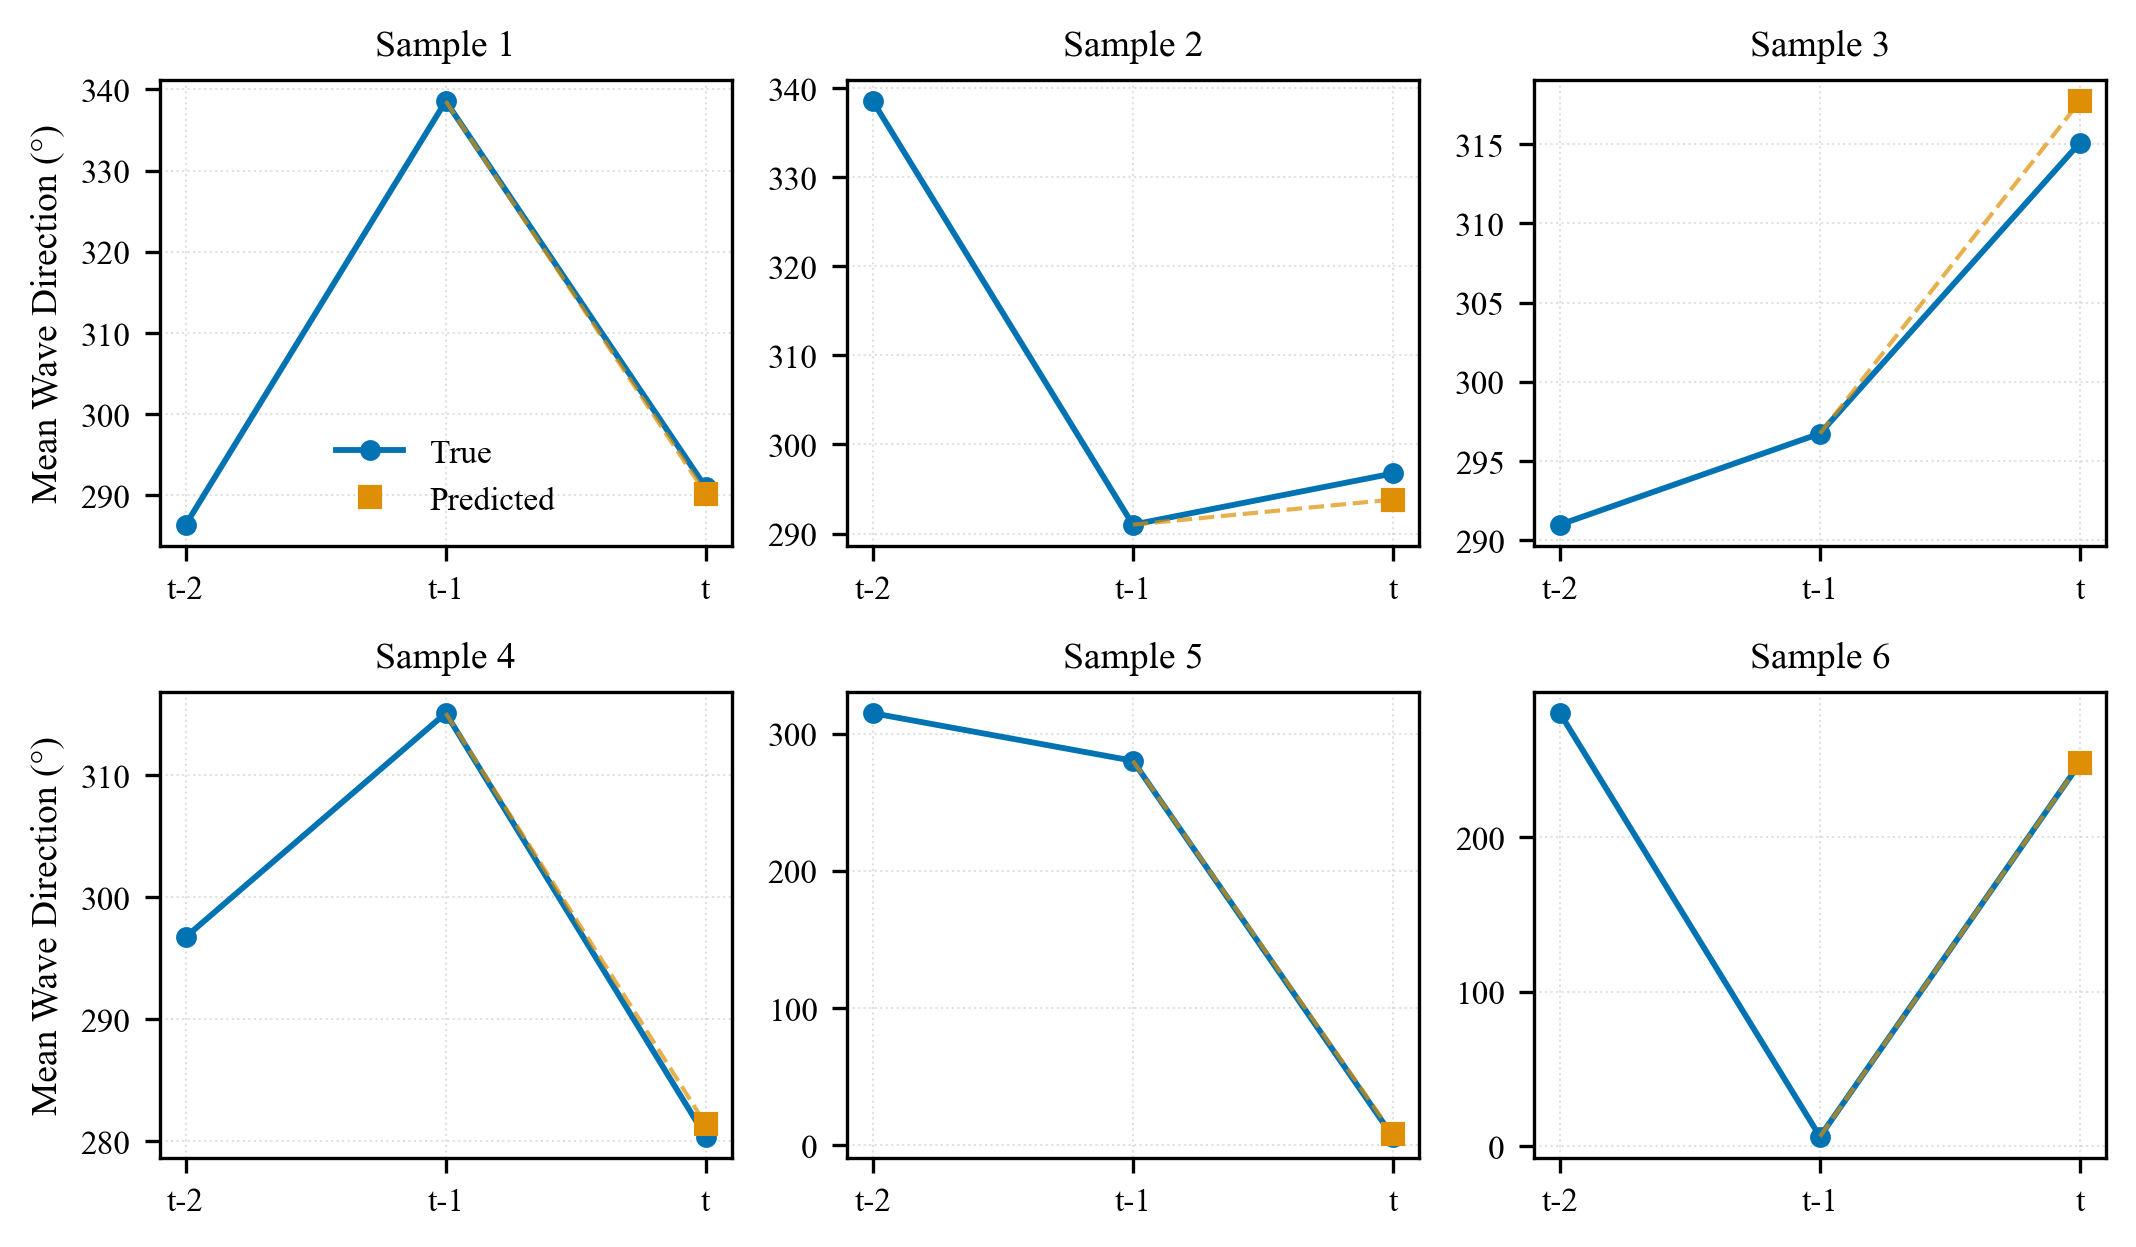

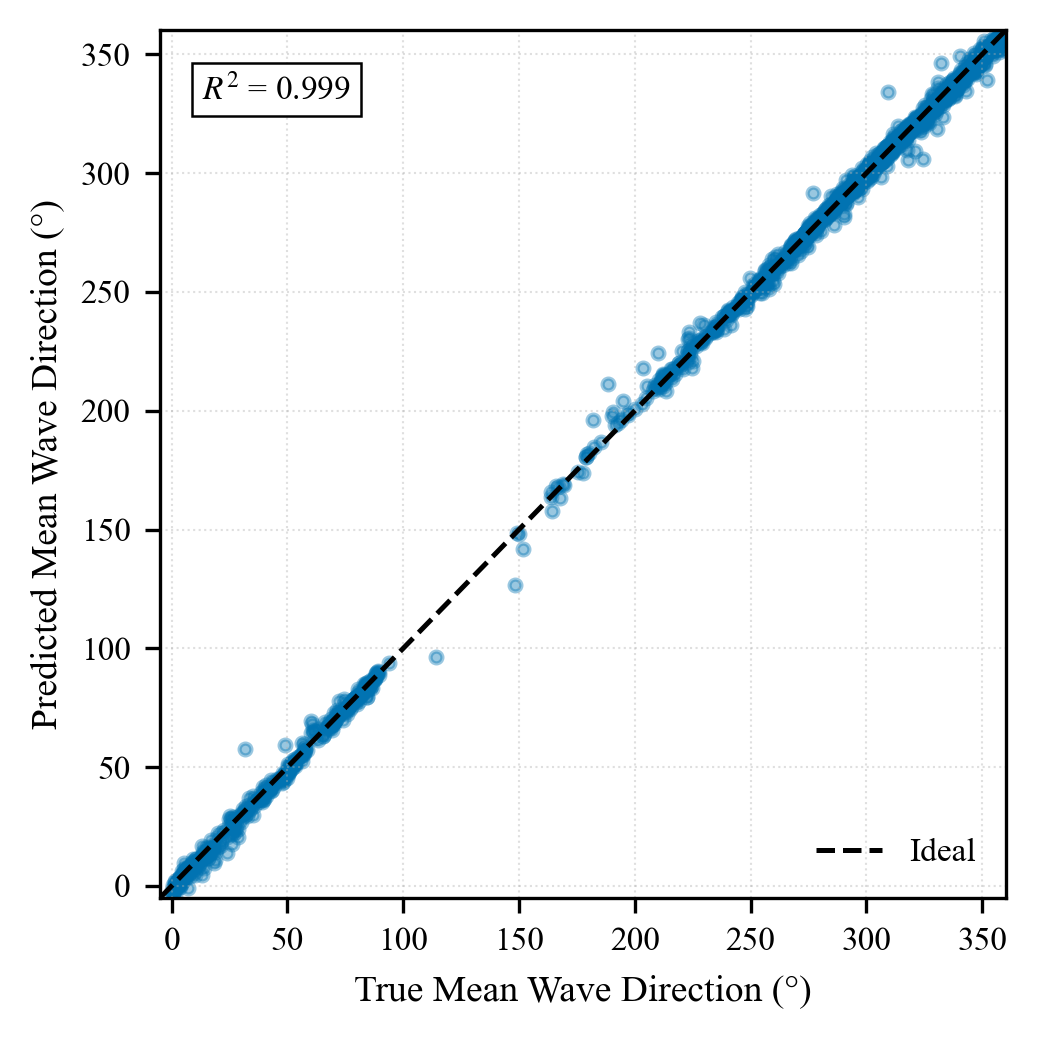

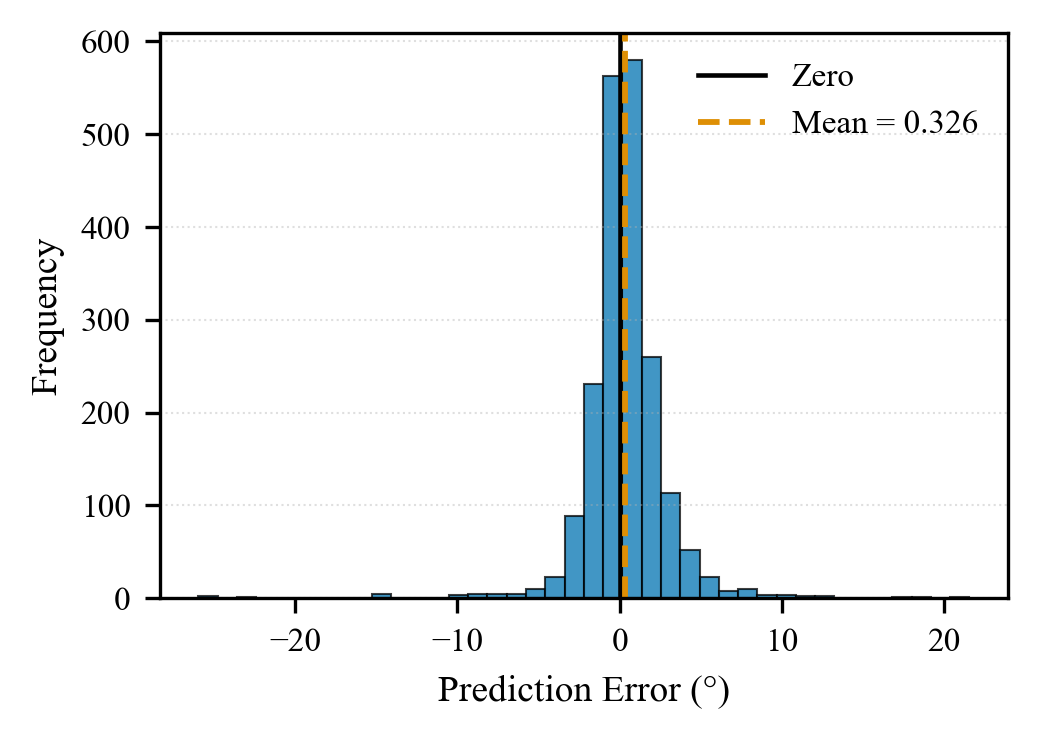

In [30]:
### 7.2 Performance Metrics and Publication-Ready Visualization (IEEE)

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Variable names and physical units
# -------------------------------
VAR_UNITS = {
    "mwp": "Mean Wave Period (s)",
    "swh": "Significant Wave Height (m)",
    "mwd": "Mean Wave Direction (°)"
}

# IEEE-style defaults
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

COLOR_TRUE = "#0173B2"
COLOR_PRED = "#DE8F05"

# -------------------------------
# Loop over variables
# -------------------------------
for i, var_name in enumerate(vars_pred):

    print("\n" + "=" * 60)
    print(f" Variable: {var_name.upper()} — {VAR_UNITS[var_name]}")
    print("=" * 60)

    y_true = yte_merged[:, i]
    y_pred = y_pred_merged[:, i]
    errors = y_true - y_pred

    # ---- Metrics ----
    mse = np.mean(errors**2)
    rmse = np.sqrt(mse)
    nrmse = rmse / (y_true.max() - y_true.min())
    mae = np.mean(np.abs(errors))
    nmae = mae / (y_true.max() - y_true.min())
    r2 = 1 - np.sum(errors**2) / np.sum((y_true - y_true.mean())**2)

    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  NRMSE : {nrmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  NMAE : {nmae:.4f}")
    print(f"  R²   : {r2:.4f}")

    # ==================================================
    # Temporal evolution (IEEE double-column width)
    # ==================================================
    fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.2), dpi=300)
    axes = axes.flatten()

    for k in range(min(6, len(y_true) - 2)):
        ax = axes[k]

        hist_vals = y_true[k:k+3]
        pred_val = y_pred[k+2]
        time_steps = ["t-2", "t-1", "t"]

        ax.plot(time_steps, hist_vals, "o-",
                color=COLOR_TRUE, linewidth=1.4,
                markersize=4, label="True")

        ax.plot("t", pred_val, "s",
                color=COLOR_PRED, markersize=5,
                label="Predicted")

        ax.plot(["t-1", "t"],
                [hist_vals[1], pred_val],
                "--", color=COLOR_PRED,
                linewidth=1.0, alpha=0.7)

        ax.set_title(f"Sample {k+1}")
        ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)

        if k % 3 == 0:
            ax.set_ylabel(VAR_UNITS[var_name])

    axes[0].legend(frameon=False, loc="best")
    plt.tight_layout()
    plt.savefig(f"images, figures and videos2/temporal_{var_name}.png",
                dpi=300, bbox_inches="tight")
    #plt.close()

    # ==================================================
    # Scatter plot (IEEE single-column)
    # ==================================================
    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=300)

    ax.scatter(y_true, y_pred,
               s=8, alpha=0.4,
               color=COLOR_TRUE,
               rasterized=True)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            "k--", linewidth=1.2, label="Ideal")

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    ax.set_xlabel(f"True {VAR_UNITS[var_name]}")
    ax.set_ylabel(f"Predicted {VAR_UNITS[var_name]}")

    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
    ax.legend(frameon=False, loc="lower right")

    ax.text(0.05, 0.95,
            f"$R^2$ = {r2:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="square",
                      facecolor="white",
                      edgecolor="black",
                      linewidth=0.6))

    plt.tight_layout()
    plt.savefig(f"images, figures and videos2/scatter_{var_name}.png",
                dpi=300, bbox_inches="tight")
    #plt.close()

    # ==================================================
    # Error distribution histogram (IEEE single-column)
    # ==================================================
    fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)

    ax.hist(errors, bins=40,
            color=COLOR_TRUE,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.75)

    mean_err = errors.mean()
    ax.axvline(0, color="black", linewidth=1.1, label="Zero")
    ax.axvline(mean_err, color=COLOR_PRED,
               linestyle="--", linewidth=1.4,
               label=f"Mean = {mean_err:.3f}")

    unit = VAR_UNITS[var_name].split("(")[1].strip(")")
    ax.set_xlabel(f"Prediction Error ({unit})")
    ax.set_ylabel("Frequency")

    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.4)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(f"images, figures and videos2/error_dist_{var_name}.png",
                dpi=300, bbox_inches="tight")
    #plt.close()

    print(f"  Figures saved for {var_name.upper()}")
